In [1]:
import pandas as pd

#time = [0.156139, 0.331933511, 0.1876791, 0.12291401]
time = [0.136, 0.141, 0.139, 0.122]
mem = [10804, 6324, 6337, 5841]
methods = ["Original", "SOTA-Revs", "ReverSyn-w.o.DP", "ReverSyn-DP"]

data = pd.DataFrame(dict(method=methods, time=time, memory=mem))
data

,method,time,memory
0,Original,0.136,10804
1,SOTA-Revs,0.141,6324
2,ReverSyn-w.o.DP,0.139,6337
3,ReverSyn-DP,0.122,5841


In [2]:
gpt_time = [0.508862, 1.00412, 0.822247, 0.52037]
gpt_mem = [10807, 6914, 6836, 5918]
gpt = pd.DataFrame(dict(method=methods, time=gpt_time, memory=gpt_mem))
gpt

,method,time,memory
0,Original,0.508862,10807
1,SOTA-Revs,1.004120,6914
2,ReverSyn-w.o.DP,0.822247,6836
3,ReverSyn-DP,0.520370,5918


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 300

colors = ["#FF85CA", "#8ADD67", "#F6CC58", "#60D3FF"]
sns.set_palette(colors)

hatches = ["//", "..", "--", "oo"]

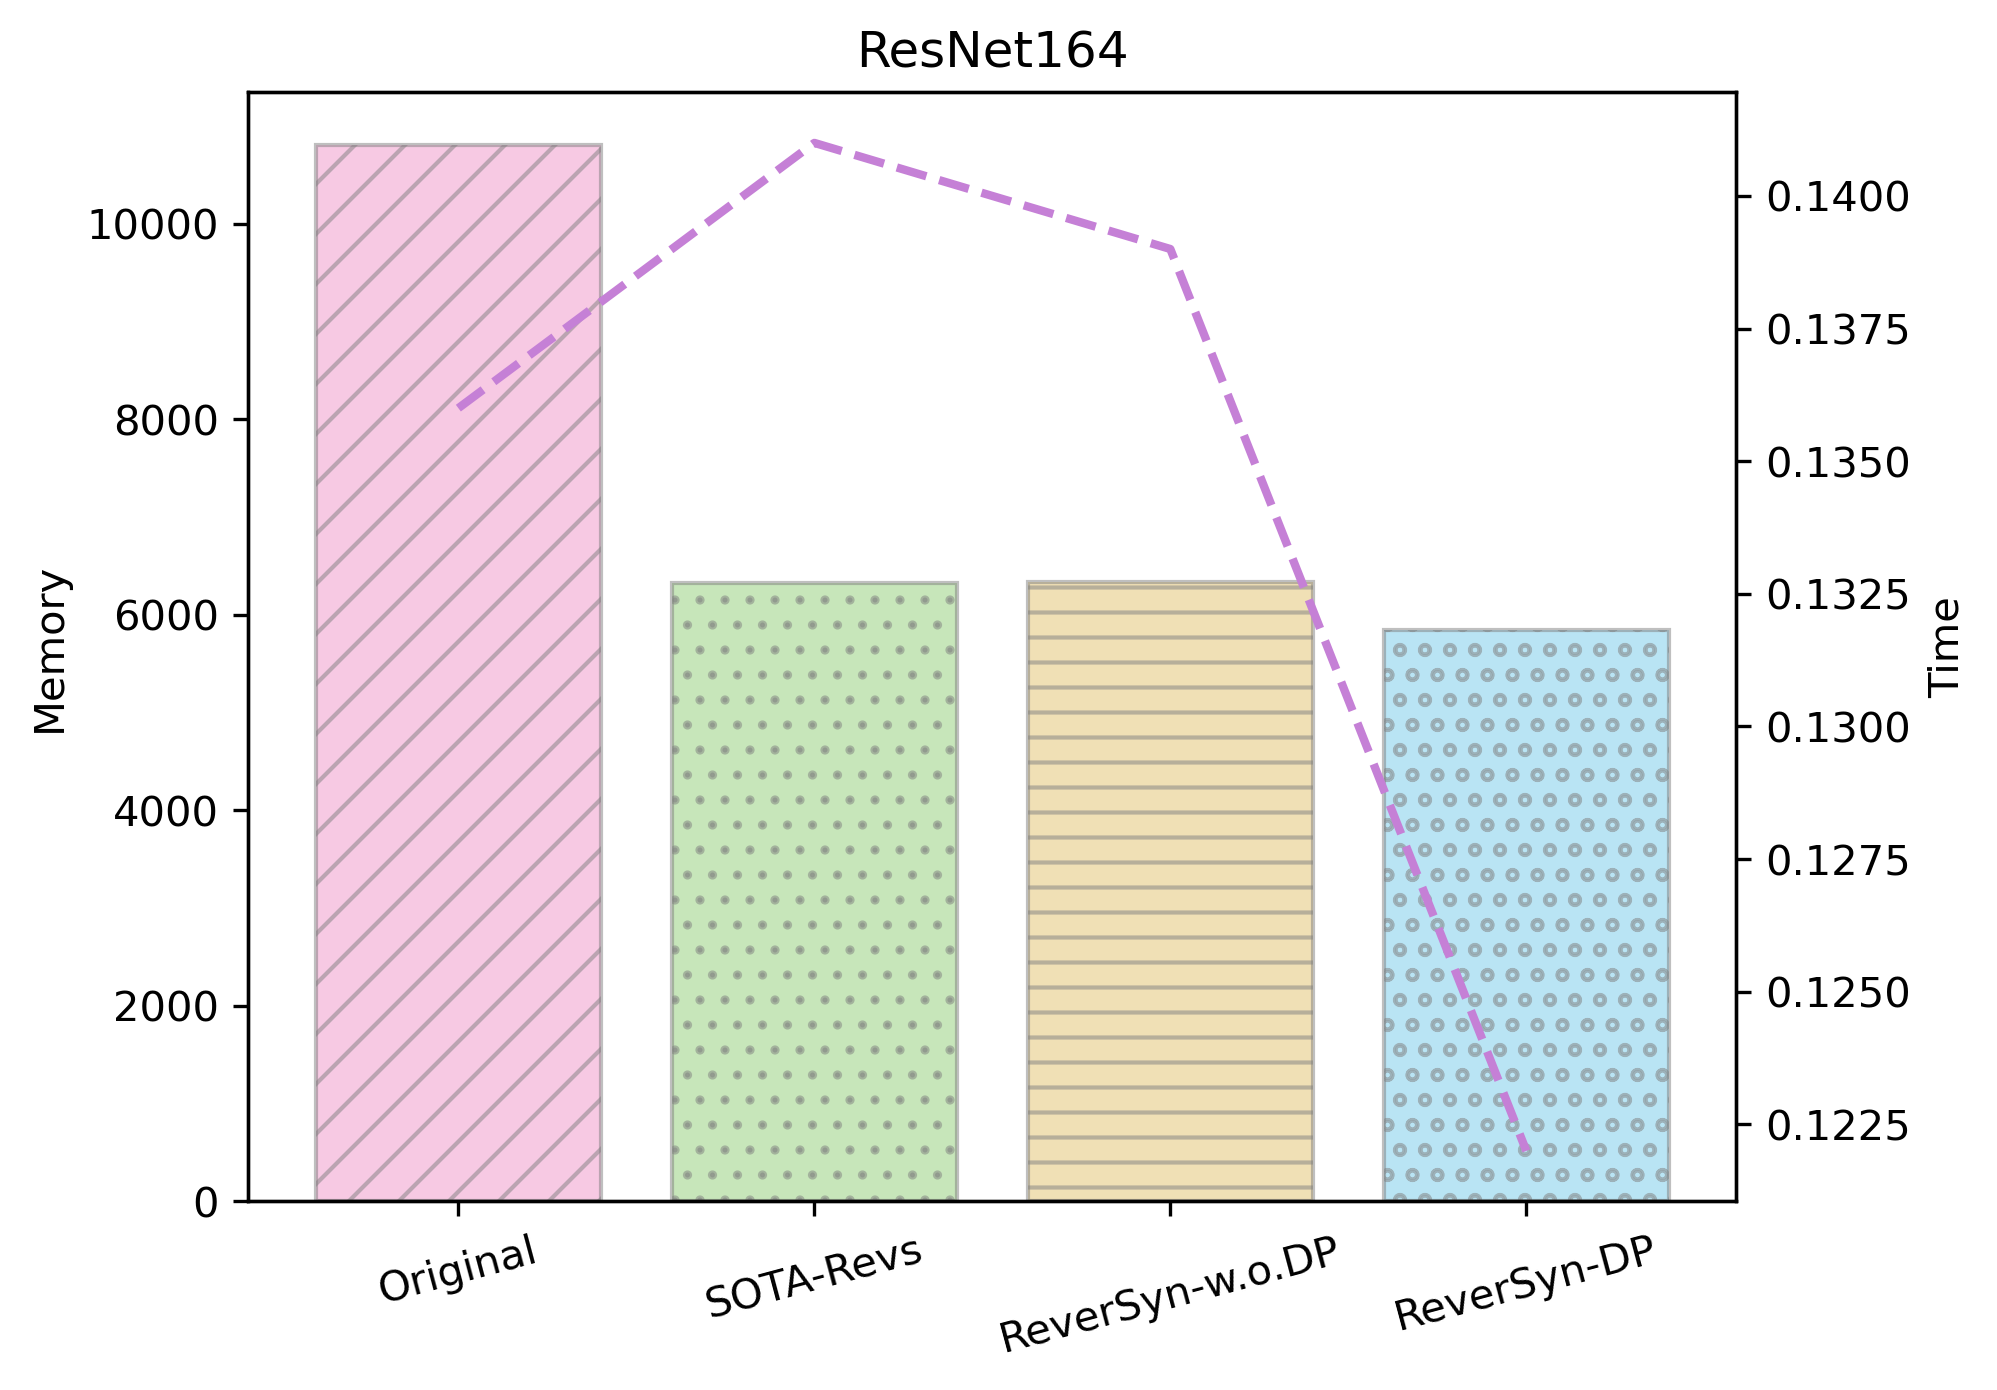

In [4]:
barchart = sns.barplot(data, x="method", y="memory", alpha=0.5)
plt.xticks(rotation=15)

linechart = sns.lineplot(data, x="method", y="time", ax=barchart.twinx(), linestyle="--", color="#C580D6", linewidth=2)
plt.xticks(rotation=15)

for i, bar in enumerate(barchart.patches):
    bar.set_hatch(hatches[i])
    bar.set_edgecolor("gray")
    
plt.title("ResNet164")
barchart.set_ylabel("Memory")
linechart.set_ylabel("Time")
barchart.set_xlabel(None)
linechart.set_xlabel(None)

plt.savefig("breakdown-resnet164.pdf", format="pdf", bbox_inches="tight", dpi=300, pad_inches=0.1)

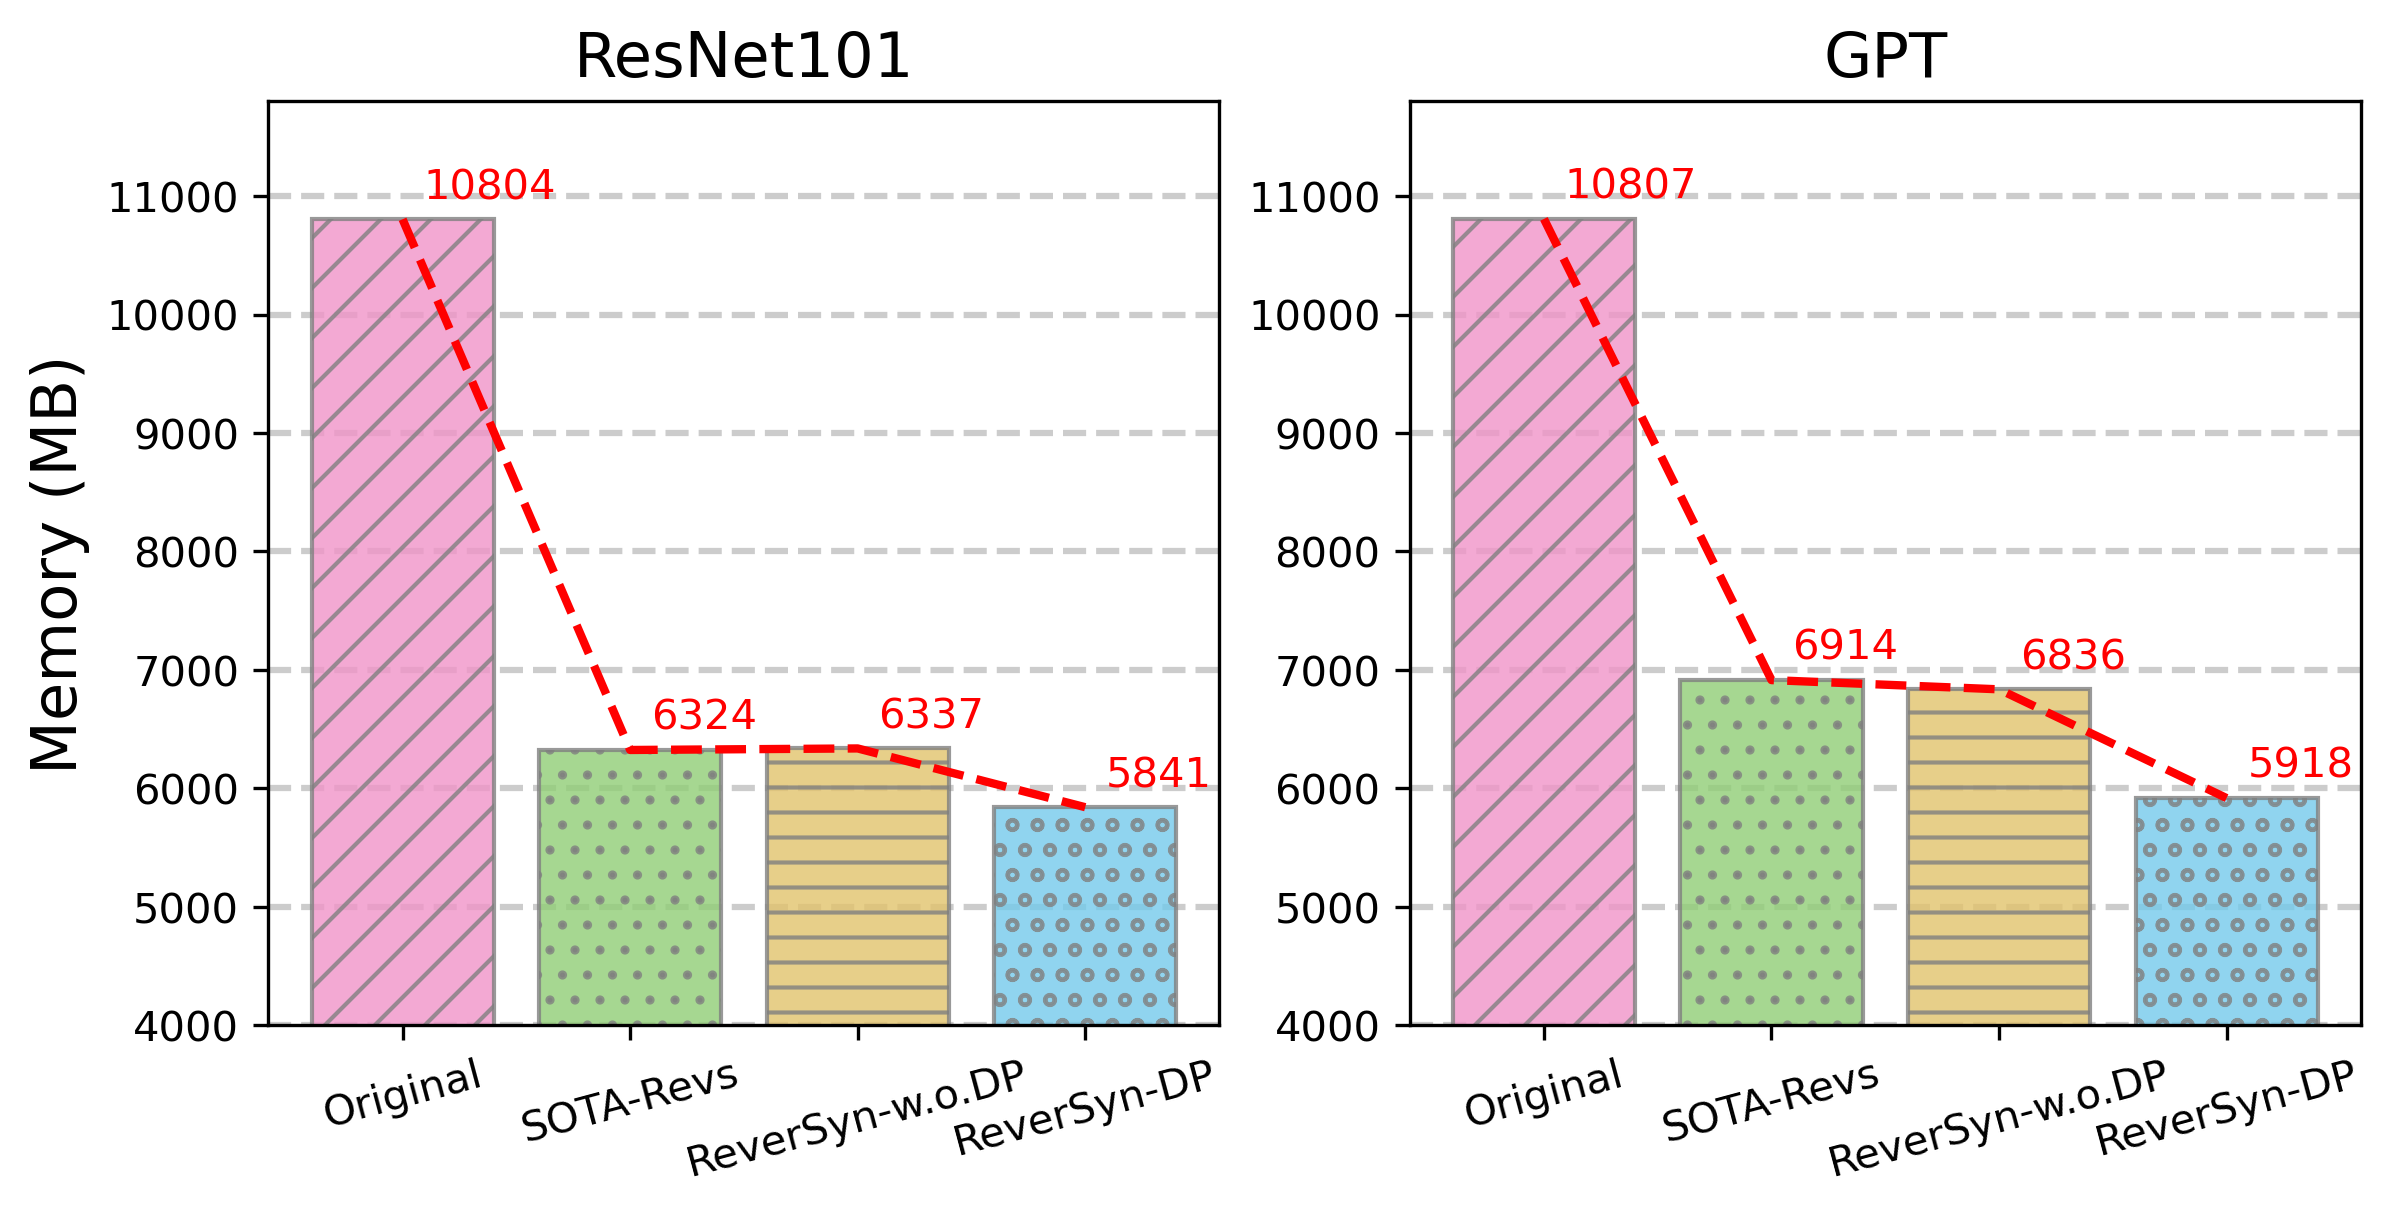

In [5]:
fig, (left, right) = plt.subplots(1, 2, figsize=(9, 4))

barchart = sns.barplot(data, x="method", y="memory", alpha=0.8, ax=left)
barchart.set_ylim(4000, 11800)
plt.xticks(rotation=15)

linechart = sns.lineplot(data, x="method", y="memory", ax=left, linestyle="--", color="red", linewidth=2)
linechart.set_ylim(4000, 11800)
plt.xticks(rotation=15)

for i, bar in enumerate(barchart.patches):
    bar.set_hatch(hatches[i])
    bar.set_edgecolor("gray")

fontsize = 15
    
left.set_title("ResNet101", fontsize=fontsize)
left.set_xticklabels(methods, rotation=15)
left.set_ylabel("Memory (MB)", fontsize=fontsize)
left.set_xlabel(None)

right.set_title("GPT", fontsize=fontsize)
gpt_bar = sns.barplot(gpt, x="method", y="memory", alpha=0.8, ax=right)
gpt_line = sns.lineplot(gpt, x="method", y="memory", ax=right, linestyle="--", color="red", linewidth=2)
gpt_bar.set_ylim(4000, 11800)
right.set_ylabel(None)
right.set_xlabel(None)

for i, bar in enumerate(gpt_bar.patches):
    bar.set_hatch(hatches[i])
    bar.set_edgecolor("gray")

x = left.get_xticks()
y = data.memory
z = gpt.memory

for i, j, k in zip(x, y, z):
    left.annotate(j, xy=(i, j), color="red", xytext=(5, 5), textcoords="offset points")
    right.annotate(k, xy=(i, k), color="red", xytext=(5, 5), textcoords="offset points")
    
for tick in left.get_yticks():
    left.axhline(y=tick, color="gray", linestyle="--", zorder=0, alpha=0.4)
    
for tick in right.get_yticks():
    right.axhline(y=tick, color="gray", linestyle="--", zorder=0, alpha=0.4)
    
plt.savefig("breakdown-memory.pdf", format="pdf", bbox_inches="tight", dpi=300)

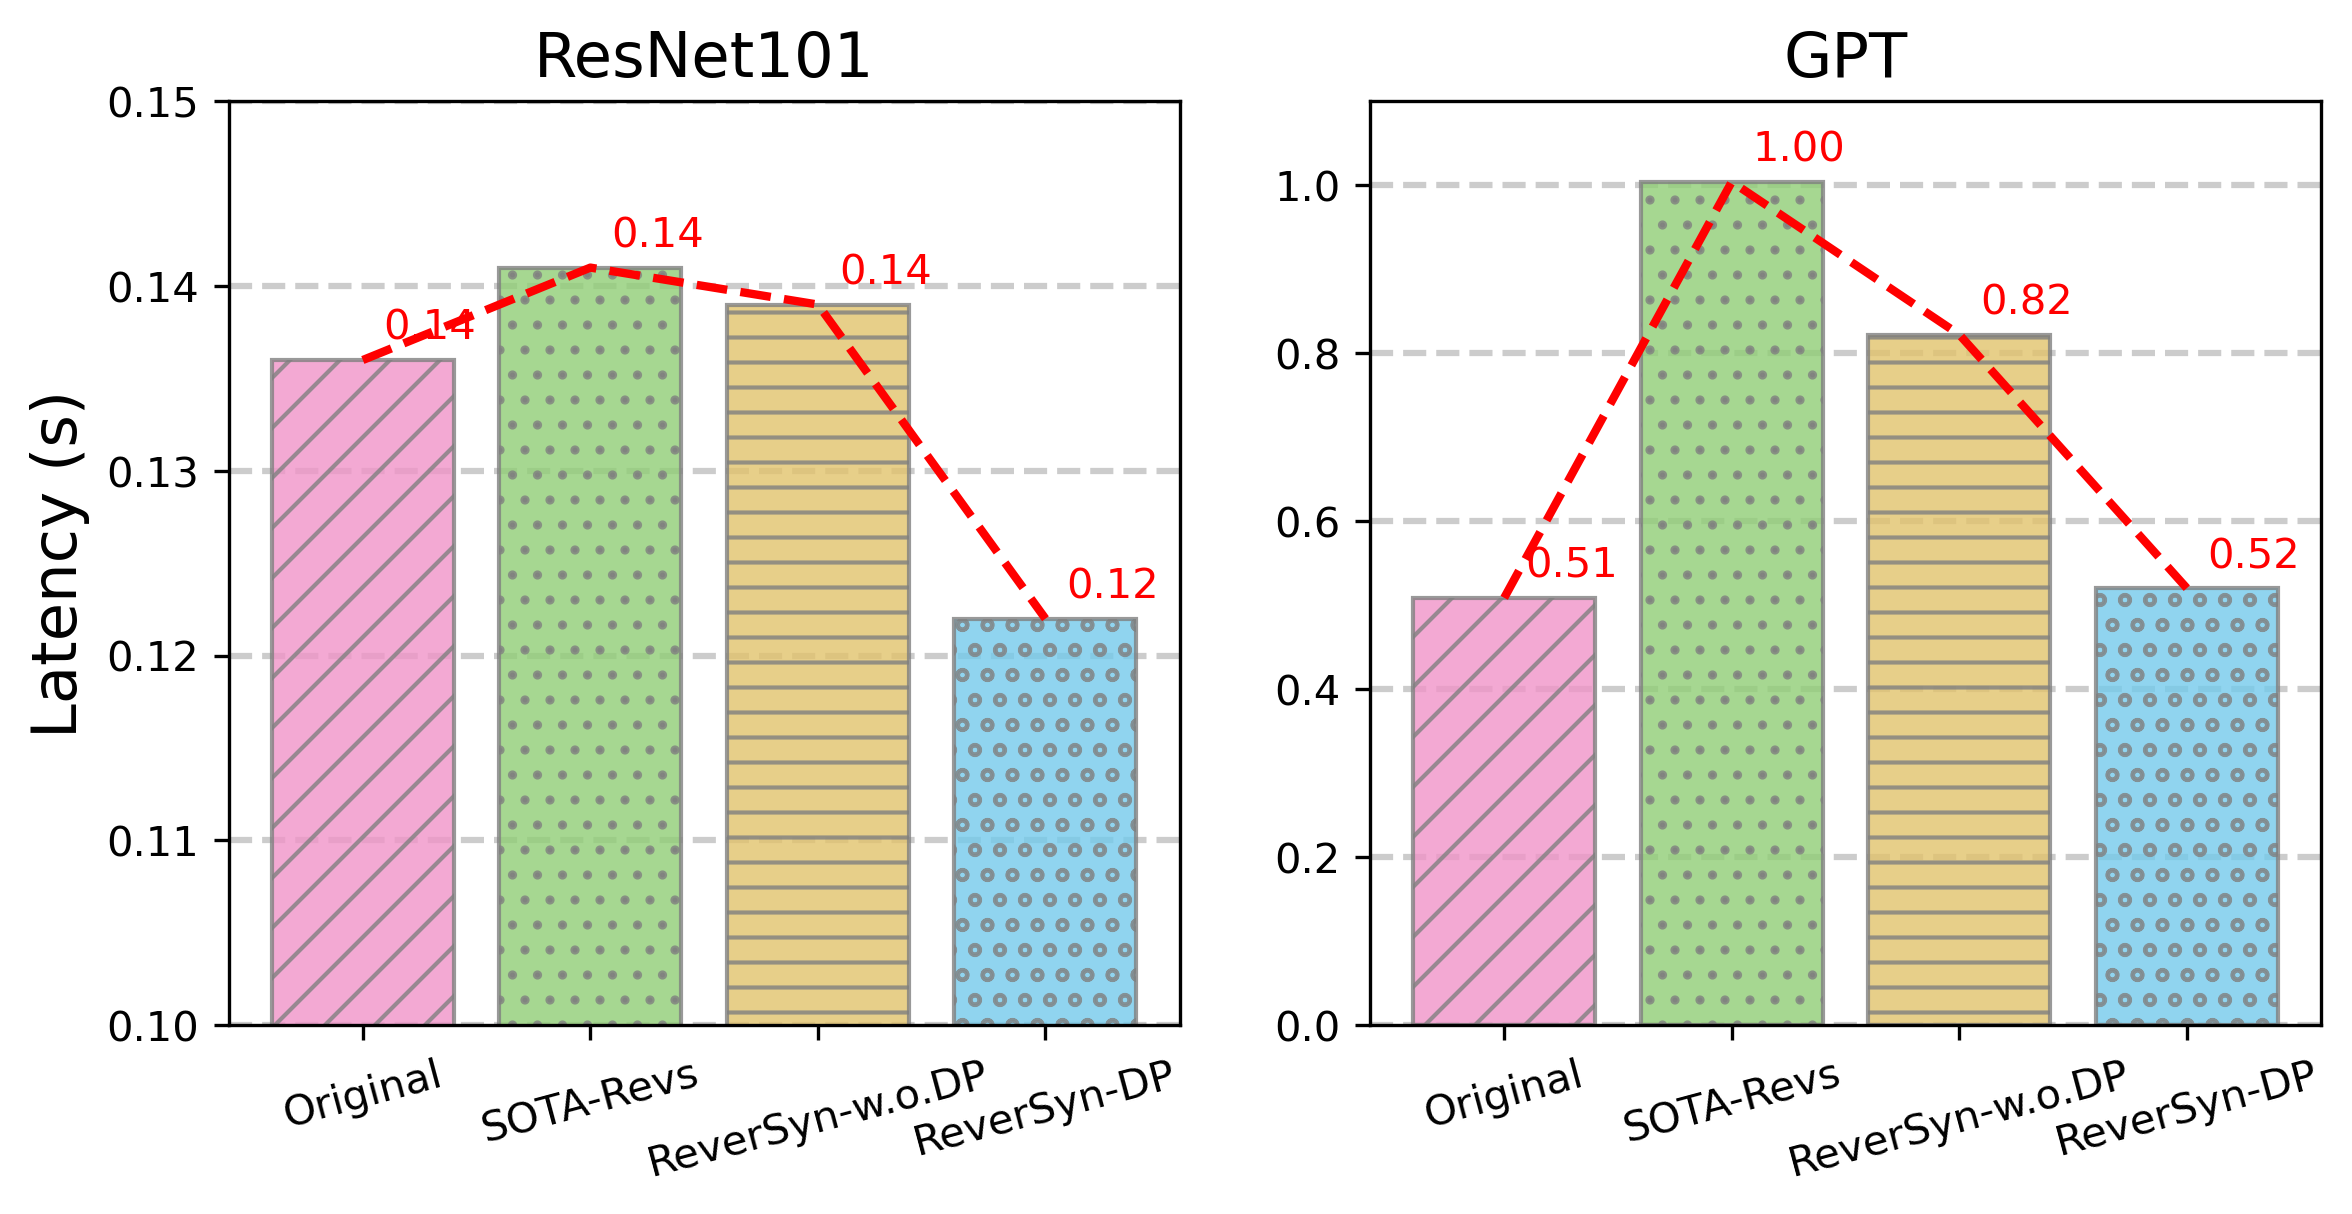

In [6]:
fig, (left, right) = plt.subplots(1, 2, figsize=(9, 4))

barchart = sns.barplot(data, x="method", y="time", alpha=0.8, ax=left)
barchart.set_ylim(0.1, 0.15)
plt.xticks(rotation=15)

linechart = sns.lineplot(data, x="method", y="time", ax=left, linestyle="--", color="red", linewidth=2)
linechart.set_ylim(0.1, 0.15)
plt.xticks(rotation=15)

for i, bar in enumerate(barchart.patches):
    bar.set_hatch(hatches[i])
    bar.set_edgecolor("gray")

fontsize = 15
    
left.set_title("ResNet101", fontsize=fontsize)
left.set_xticklabels(methods, rotation=15)
left.set_ylabel("Latency (s)", fontsize=fontsize)
left.set_xlabel(None)

right.set_title("GPT", fontsize=fontsize)
gpt_bar = sns.barplot(gpt, x="method", y="time", alpha=0.8, ax=right)
gpt_line = sns.lineplot(gpt, x="method", y="time", ax=right, linestyle="--", color="red", linewidth=2)
right.set_ylabel(None)
right.set_xlabel(None)
gpt_bar.set_ylim(0, 1.1)

for i, bar in enumerate(gpt_bar.patches):
    bar.set_hatch(hatches[i])
    bar.set_edgecolor("gray")

x = left.get_xticks()
y = data.time
z = gpt.time

for i, j, k in zip(x, y, z):
    left.annotate(f"{j:.2f}", xy=(i, j), color="red", xytext=(5, 5), textcoords="offset points")
    right.annotate(f"{k:.2f}", xy=(i, k), color="red", xytext=(5, 5), textcoords="offset points")
    
for tick in left.get_yticks():
    left.axhline(y=tick, color="gray", linestyle="--", zorder=0, alpha=0.4)
    
for tick in right.get_yticks():
    right.axhline(y=tick, color="gray", linestyle="--", zorder=0, alpha=0.4)
    
plt.savefig("breakdown-latency.pdf", format="pdf", bbox_inches="tight", dpi=300)